In [5]:
# loading dataset
from datasets import load_dataset

# data processing
import pandas as pd
import numpy as np
import math

# charts
import matplotlib.pyplot as plt
import seaborn as sns

# Pretreained HerBERT
from transformers import pipeline
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [6]:
dataset = load_dataset ("allegro/klej-polemo2-in", split ="test")

df = pd.DataFrame(dataset)

label_mapping = {
    '__label__meta_minus_m': 'Negative',
    '__label__meta_plus_m': 'Positive',
    '__label__meta_zero': 'Neutral',
}

df['text_length'] = df['sentence'].apply(len)

# remove ambigous target
df = df[df['target'] != '__label__meta_amb']

# map targets to more readable names
df['target'] = df['target'].map(label_mapping)

In [7]:
reviews_texts = df['sentence'].tolist()

model_label_mapping = {
    'neutral': 'Neutral',
    'negative': 'Negative',
    'positive': 'Positive'
}

classifier = pipeline(
    "text-classification",
    model="Voicelab/herbert-base-cased-sentiment",
    device="cuda",
)

pred_logits = classifier(
    reviews_texts,
    batch_size=32,
    truncation=True,
    max_length=512,
    stride=64,
    top_k=None,    # returns class evaluations
    function_to_apply="none"
)

print(pred_logits[0])
print(pred_logits[1])
print(pred_logits[2])

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8215.15it/s]
BertForSequenceClassification LOAD REPORT from: Voicelab/herbert-base-cased-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'label': 'positive', 'score': 4.394119739532471}, {'label': 'neutral', 'score': -0.6998867988586426}, {'label': 'negative', 'score': -3.266897678375244}]
[{'label': 'negative', 'score': 3.611727237701416}, {'label': 'neutral', 'score': -0.15275327861309052}, {'label': 'positive', 'score': -3.161181688308716}]
[{'label': 'neutral', 'score': 1.3110870122909546}, {'label': 'positive', 'score': 0.06864441186189651}, {'label': 'negative', 'score': -1.1366853713989258}]


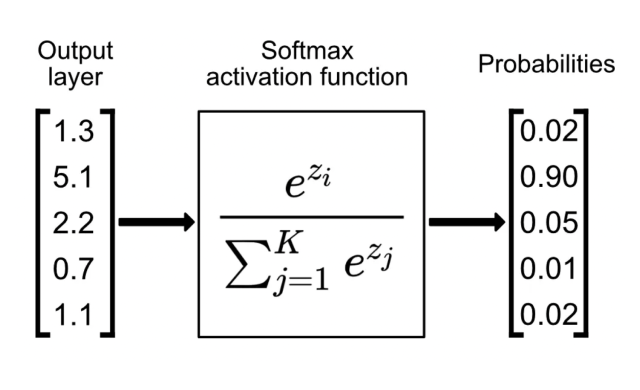

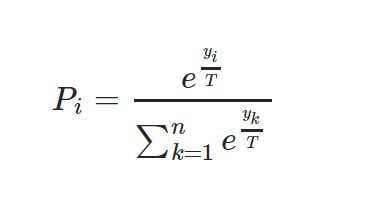


===== TEMP 0.3 =====

              precision    recall  f1-score   support

    Negative       0.97      0.86      0.91       300
     Neutral       0.29      0.10      0.15       117
    Positive       0.63      0.98      0.77       197

    accuracy                           0.75       614
   macro avg       0.63      0.65      0.61       614
weighted avg       0.73      0.75      0.72       614



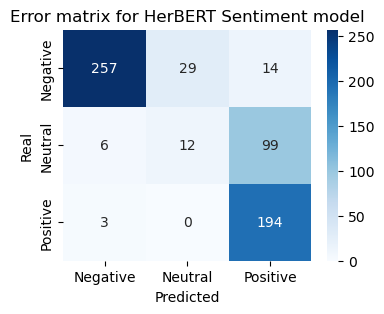



===== TEMP 0.5 =====

              precision    recall  f1-score   support

    Negative       0.97      0.87      0.92       300
     Neutral       0.45      0.17      0.25       117
    Positive       0.64      0.98      0.78       197

    accuracy                           0.77       614
   macro avg       0.69      0.67      0.65       614
weighted avg       0.77      0.77      0.74       614



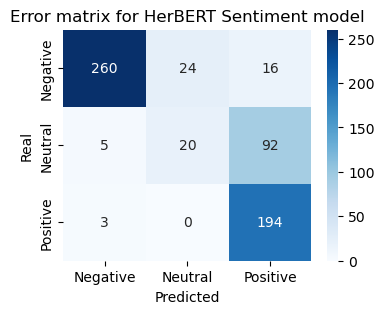



===== TEMP 0.7 =====

              precision    recall  f1-score   support

    Negative       0.96      0.85      0.90       300
     Neutral       0.35      0.14      0.20       117
    Positive       0.64      0.98      0.78       197

    accuracy                           0.76       614
   macro avg       0.65      0.66      0.63       614
weighted avg       0.74      0.76      0.73       614



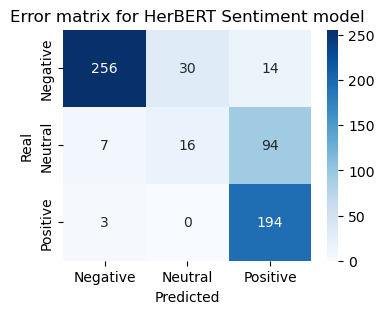



===== TEMP 1.0 =====

              precision    recall  f1-score   support

    Negative       0.94      0.84      0.89       300
     Neutral       0.33      0.15      0.20       117
    Positive       0.66      0.98      0.79       197

    accuracy                           0.75       614
   macro avg       0.64      0.66      0.63       614
weighted avg       0.73      0.75      0.72       614



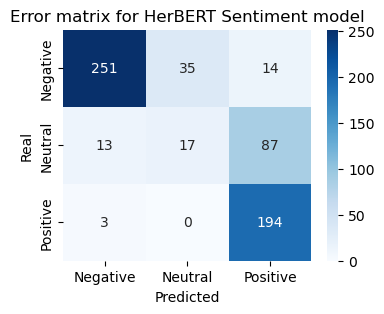



===== TEMP 1.2 =====

              precision    recall  f1-score   support

    Negative       0.95      0.82      0.88       300
     Neutral       0.36      0.19      0.25       117
    Positive       0.66      0.98      0.79       197

    accuracy                           0.75       614
   macro avg       0.66      0.67      0.64       614
weighted avg       0.75      0.75      0.73       614



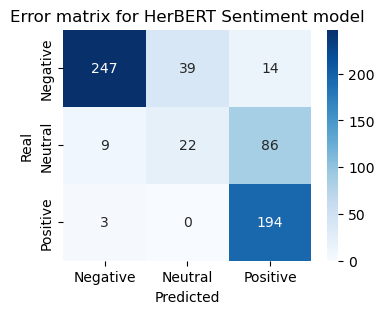



===== TEMP 1.5 =====

              precision    recall  f1-score   support

    Negative       0.94      0.82      0.88       300
     Neutral       0.43      0.25      0.31       117
    Positive       0.68      0.98      0.80       197

    accuracy                           0.76       614
   macro avg       0.68      0.68      0.66       614
weighted avg       0.76      0.76      0.75       614



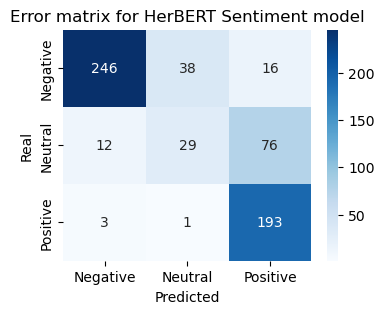



===== TEMP 1.7 =====

              precision    recall  f1-score   support

    Negative       0.94      0.80      0.86       300
     Neutral       0.34      0.18      0.23       117
    Positive       0.65      0.98      0.78       197

    accuracy                           0.74       614
   macro avg       0.64      0.65      0.63       614
weighted avg       0.73      0.74      0.72       614



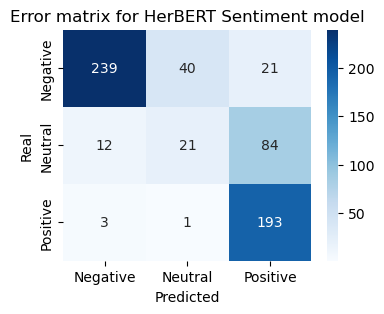



===== TEMP 2.0 =====

              precision    recall  f1-score   support

    Negative       0.94      0.77      0.85       300
     Neutral       0.39      0.28      0.33       117
    Positive       0.69      0.98      0.81       197

    accuracy                           0.75       614
   macro avg       0.67      0.68      0.66       614
weighted avg       0.75      0.75      0.74       614



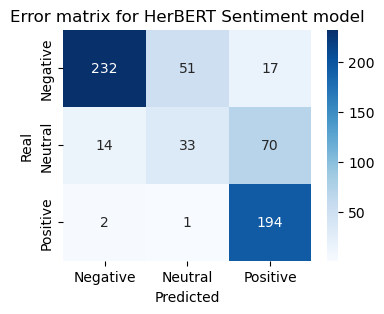


[0.754071661237785, 0.7719869706840391, 0.758957654723127, 0.752442996742671, 0.754071661237785, 0.762214983713355, 0.737785016286645, 0.747557003257329]
[0.7196564244326287, 0.744127959313904, 0.7288693383380987, 0.7239489425474966, 0.7324295794852217, 0.7451892033165054, 0.716477982621568, 0.736401093001984]


In [8]:
labels = ["positive", "neutral", "negative"]
temperatures = [0.3, 0.5, 0.7,  1.0, 1.2, 1.5,  1.7,  2.0]
threshold = 0.04

accuracy_scores = []
f1_scores = []

for temp in temperatures:
    temp_preds = []

    for review_logits in pred_logits:
        current_labels = [pred['label'] for pred in review_logits]

        scores = [pred['score'] for pred in review_logits]
        scores = np.array(scores)

        # calculate softmax
        exp_values = np.exp(scores / temp)
        preds = exp_values / np.sum(exp_values)

        # filter
        filtered_preds = preds.copy()
        filtered_preds[filtered_preds < threshold] = 0.0
        filtered_preds /= np.sum(filtered_preds)

        # randomize with weights
        final_pred = np.random.choice(current_labels, p=filtered_preds).item()
        temp_preds.append(final_pred)

    temp_preds = [model_label_mapping.get(lbl, lbl) for lbl in temp_preds]

    print(f"\n===== TEMP {temp} =====\n")
    print(classification_report(df['target'], temp_preds))

    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(df['target'], temp_preds, labels=['Negative', 'Neutral', 'Positive'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.ylabel('Real')
    plt.xlabel('Predicted')
    plt.title('Error matrix for HerBERT Sentiment model')
    plt.show()

    print()
    
    accuracy = accuracy_score(df['target'], temp_preds)
    f1 = f1_score(df['target'], temp_preds, average='weighted')

    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    
print(accuracy_scores)
print(f1_scores)



In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(temperatures, accuracy_scores, marker='o', linewidth=2, label='Accuracy', color='#1f77b4')
ax.plot(temperatures, f1_scores, marker='s', linewidth=2, linestyle='--', label='F1-Score (Weighted)', color='#ff7f0e')

ax.set_xlabel('Temperature', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Score', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Trends of Accuracy and F1-Score across Temperatures', fontsize=14, fontweight='bold', pad=15)

ax.set_xticks(temperatures)

ax.set_ylim(0.0, 1.05)

ax.legend(fontsize=11, loc='lower left', frameon=True)

plt.tight_layout()